# Exploratory Data Analysis: Customer Repeat Order Prediction

Goal: understand customer purchase behavior before building the prediction target and features.

Data: Online Retail II (UK online wholesaler), Dec 2009 to Dec 2011.
After cleaning, one row in `orders` = one customer on one day.

- 32,878 orders
- 5,852 customers
- Date range: 2009-12-01 to 2011-12-09

In [34]:
import sys
sys.path.append("..")

import pandas as pd
import matplotlib.pyplot as plt
from src.data import load_clean

orders, returns = load_clean("C:/Users/APTIKA/OneDrive/Documents/RIMA/customer_repeat_order/data/raw/online_retail_II.csv")

In [35]:
orders.to_parquet("../data/processed/orders.parquet")
returns.to_parquet("../data/processed/returns.parquet")

In [36]:
orders.head(10)

,customer_id,order_date,revenue,n_items,n_products,n_invoices,country
0,12346,2010-03-02,27.05,5,5,1,United Kingdom
1,12346,2010-06-28,142.31,19,19,1,United Kingdom
2,12346,2011-01-18,77183.60,74215,1,1,United Kingdom
3,12347,2010-10-31,611.53,509,40,1,Iceland
4,12347,2010-12-07,711.79,319,31,1,Iceland
5,12347,2011-01-26,475.39,315,29,1,Iceland
6,12347,2011-04-07,636.25,483,24,1,Iceland
7,12347,2011-06-09,382.52,196,18,1,Iceland
8,12347,2011-08-02,584.91,277,22,1,Iceland
9,12347,2011-10-31,1294.32,676,47,1,Iceland


In [37]:
orders.sample(10, random_state=42)

,customer_id,order_date,revenue,n_items,n_products,n_invoices,country
31246,17961,2011-03-16,28.18,22,9,1,United Kingdom
30705,17869,2010-08-27,230.27,335,25,1,United Kingdom
4246,13090,2011-11-08,1833.69,495,32,1,United Kingdom
13423,14709,2010-08-08,311.38,156,15,1,United Kingdom
11862,14498,2010-12-13,166.22,70,13,1,United Kingdom
15878,15129,2011-06-14,428.95,136,11,2,United Kingdom
25089,16872,2010-09-02,115.45,79,4,1,United Kingdom
27418,17339,2011-09-06,183.36,136,5,1,United Kingdom
23100,16523,2011-04-15,461.70,258,20,2,United Kingdom
5466,13313,2010-03-22,310.98,160,16,1,United Kingdom


In [38]:
returns.head(10)

,invoice,stock_code,Description,quantity,invoice_date,price,customer_id,country,is_cancel,order_date
178,C489449,22087,PAPER BUNTING WHITE LACE,-12,2009-12-01 10:33:00,2.95,16321,Australia,True,2009-12-01
179,C489449,85206A,CREAM FELT EASTER EGG BASKET,-6,2009-12-01 10:33:00,1.65,16321,Australia,True,2009-12-01
180,C489449,21895,POTTING SHED SOW 'N' GROW SET,-4,2009-12-01 10:33:00,4.25,16321,Australia,True,2009-12-01
181,C489449,21896,POTTING SHED TWINE,-6,2009-12-01 10:33:00,2.10,16321,Australia,True,2009-12-01
182,C489449,22083,PAPER CHAIN KIT RETRO SPOT,-12,2009-12-01 10:33:00,2.95,16321,Australia,True,2009-12-01
183,C489449,21871,SAVE THE PLANET MUG,-12,2009-12-01 10:33:00,1.25,16321,Australia,True,2009-12-01
184,C489449,84946,ANTIQUE SILVER TEA GLASS ETCHED,-12,2009-12-01 10:33:00,1.25,16321,Australia,True,2009-12-01
185,C489449,84970S,HANGING HEART ZINC T-LIGHT HOLDER,-24,2009-12-01 10:33:00,0.85,16321,Australia,True,2009-12-01
186,C489449,22090,PAPER BUNTING RETRO SPOTS,-12,2009-12-01 10:33:00,2.95,16321,Australia,True,2009-12-01
196,C489459,90200A,PURPLE SWEETHEART BRACELET,-3,2009-12-01 10:44:00,4.25,17592,United Kingdom,True,2009-12-01


In [39]:
orders.info()

<class 'pandas.DataFrame'>
RangeIndex: 32878 entries, 0 to 32877
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   customer_id  32878 non-null  int64         
 1   order_date   32878 non-null  datetime64[us]
 2   revenue      32878 non-null  float64       
 3   n_items      32878 non-null  int64         
 4   n_products   32878 non-null  int64         
 5   n_invoices   32878 non-null  int64         
 6   country      32878 non-null  str           
dtypes: datetime64[us](1), float64(1), int64(4), str(1)
memory usage: 2.2 MB


## 1. How many orders does a typical customer place?

Question: how long is a typical purchase history? This decides whether history-based features (e.g. average gap between orders) are reliable.

count    5852.000000
mean        5.618250
std         9.916427
min         1.000000
25%         1.000000
50%         3.000000
75%         6.000000
max       247.000000
dtype: float64
hanya 1 order: 0.28588516746411485 | >=5 order: 0.34962406015037595


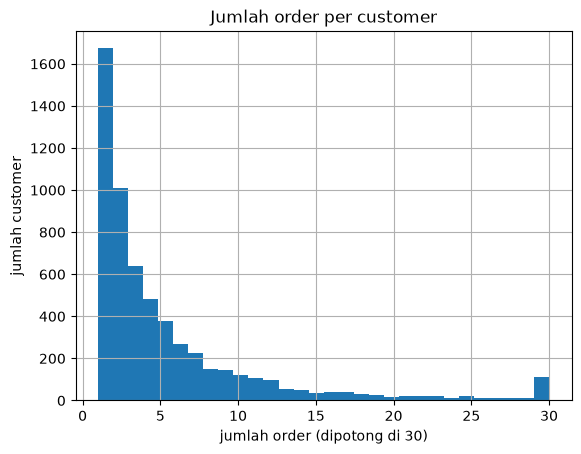

In [40]:
oc = orders.groupby("customer_id").size()
print(oc.describe())
print("hanya 1 order:", (oc == 1).mean(), "| >=5 order:", (oc >= 5).mean())
oc.clip(upper=30).hist(bins=30)
plt.title("Jumlah order per customer")
plt.xlabel("jumlah order (dipotong di 30)")
plt.ylabel("jumlah customer")
plt.show()

**Findings**
- The median customer has 3 orders. The mean is 5.6 and the maximum is 247, so the distribution is heavily right-skewed (a few very active customers).
- About 29% of customers ordered only once. About 35% ordered 5 times or more.

**Implication**
- Many customers have short histories, so features like average gap between orders are missing for the one-order group.
- I will add a `one_order` flag and use a tree-based model (LightGBM) that handles missing values natively.

## 2. How many days between two consecutive orders?

Question: how long do customers usually wait before ordering again? This helps choose the prediction window (red line = 30 days).

count    27026.000000
mean        59.288241
std         78.286630
min          1.000000
25%         13.000000
50%         32.000000
75%         70.000000
90%        148.000000
max        714.000000
Name: gap, dtype: float64


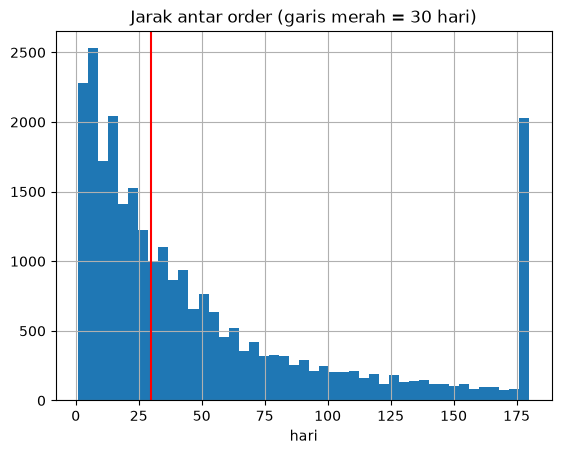

In [41]:
o = orders.sort_values(["customer_id", "order_date"]).copy()
o["gap"] = o.groupby("customer_id")["order_date"].diff().dt.days
print(o["gap"].dropna().describe(percentiles=[.25, .5, .75, .9]))
o["gap"].dropna().clip(upper=180).hist(bins=45)
plt.axvline(30, color="red")
plt.title("Jarak antar order (garis merah = 30 hari)")
plt.xlabel("hari")
plt.show()

**Findings**
- The median gap between orders is 32 days. 75% of gaps are 70 days or shorter, and the 90th percentile is about 148 days.
- The distribution has a long right tail.

**Implication**
- A 30-day prediction window is close to the typical repurchase cycle, so it is a reasonable choice: not too short to be rare, not too long to be useless for follow-up.
- Recency compared with a customer's own usual gap should be a strong feature.

## 3. Is there seasonality in orders?

Question: do order volumes change across months? This affects how we compare model performance across cutoff dates.

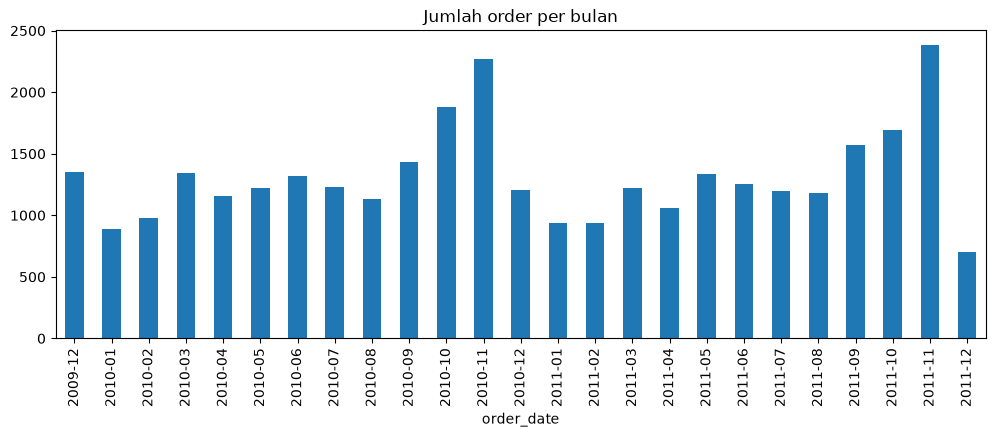

In [42]:
monthly = orders.groupby(orders["order_date"].dt.to_period("M")).size()
monthly.plot(kind="bar", figsize=(12, 4), title="Jumlah order per bulan")
plt.show()

**Findings**
- Orders peak in October and November (November 2010: ~2,266 orders, November 2011: ~2,383) and are lowest in January and February (~900 to 940).
- December 2011 looks low only because the data ends on 9 December.

**Implication**
- Add `cutoff_month` as a feature.
- Do not compare results across months without considering the base rate of that month.
- The last usable cutoff must leave a full 30-day window before the data ends.

## 4. Base rate: how many customers repeat within 30 days?

Question: of customers who have ever purchased before a given cutoff date, what share buy again in the next 30 days? This is the "random guess" benchmark for the model.

In [43]:
def base_rate(cutoff, window=30):
    c = pd.Timestamp(cutoff)
    hist = set(orders.loc[orders["order_date"] < c, "customer_id"])
    fut = set(orders.loc[(orders["order_date"] >= c) &
                         (orders["order_date"] < c + pd.Timedelta(days=window)), "customer_id"])
    return len(hist), round(len(hist & fut) / len(hist), 3)

for c in ["2010-06-01", "2010-12-01", "2011-06-01", "2011-11-01"]:
    print(c, base_rate(c))

2010-06-01 (2684, 0.286)
2010-12-01 (4239, 0.191)
2011-06-01 (4908, 0.18)
2011-11-01 (5633, 0.261)


**Findings**

| Cutoff | Customers with history | Repeat within 30 days |
|---|---|---|
| 2010-06-01 | 2,684 | 28.6% |
| 2010-12-01 | 4,239 | 19.1% |
| 2011-06-01 | 4,908 | 18.0% |
| 2011-11-01 | 5,633 | 26.1% |

- The base rate ranges from about 18% to 29% depending on the month.

**Implication**
- The classes are moderately imbalanced, so `class_weight` is enough and SMOTE is not needed.
- If we contact customers at random, we find only 18% to 29% repeaters. The model must beat this: lift will be measured against the base rate of the same cutoff.

## 5. How concentrated is revenue?

Question: how much of total revenue comes from the top customers? This shows how much the follow-up priority matters for the business.

20% teratas menyumbang: 0.771508146034585


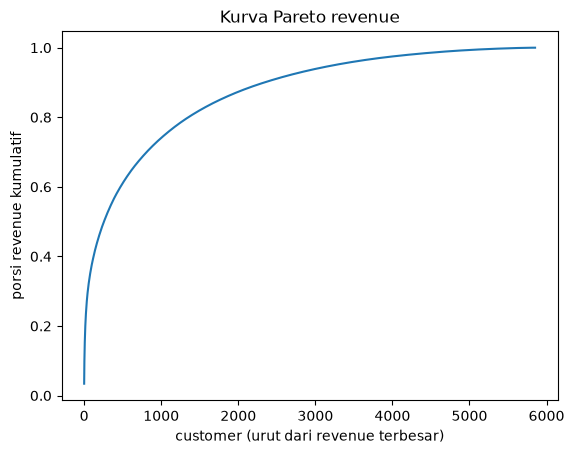

In [44]:
rev = orders.groupby("customer_id")["revenue"].sum().sort_values(ascending=False)
print("20% teratas menyumbang:", rev.head(int(len(rev) * 0.2)).sum() / rev.sum())
(rev.cumsum() / rev.sum()).reset_index(drop=True).plot(title="Kurva Pareto revenue")
plt.xlabel("customer (urut dari revenue terbesar)")
plt.ylabel("porsi revenue kumulatif")
plt.show()

**Findings**
- The top 20% of customers generate about 77% of revenue.

**Implication**
- Contacting the right customers matters a lot for revenue.
- Later, I can compare the model not only on hit rate but also on the revenue of the customers it prioritizes.

## Summary: what EDA means for the modeling design

| Finding | Design decision |
|---|---|
| Median 3 orders, 29% single-order | `one_order` flag, LightGBM handles missing values |
| Median gap 32 days | Prediction window = 30 days |
| Peak in Oct to Nov | `cutoff_month` feature, compare against same-month base rate |
| Base rate 18% to 29% | `class_weight`, no SMOTE |
| Top 20% of customers = 77% of revenue | Evaluate lift and recall at top 20%, consider revenue-weighted view |
| Data ends 2011-12-09 | Last cutoff 2011-11-01, so the 30-day window is complete |

Next step: build features and the target with a cutoff date.